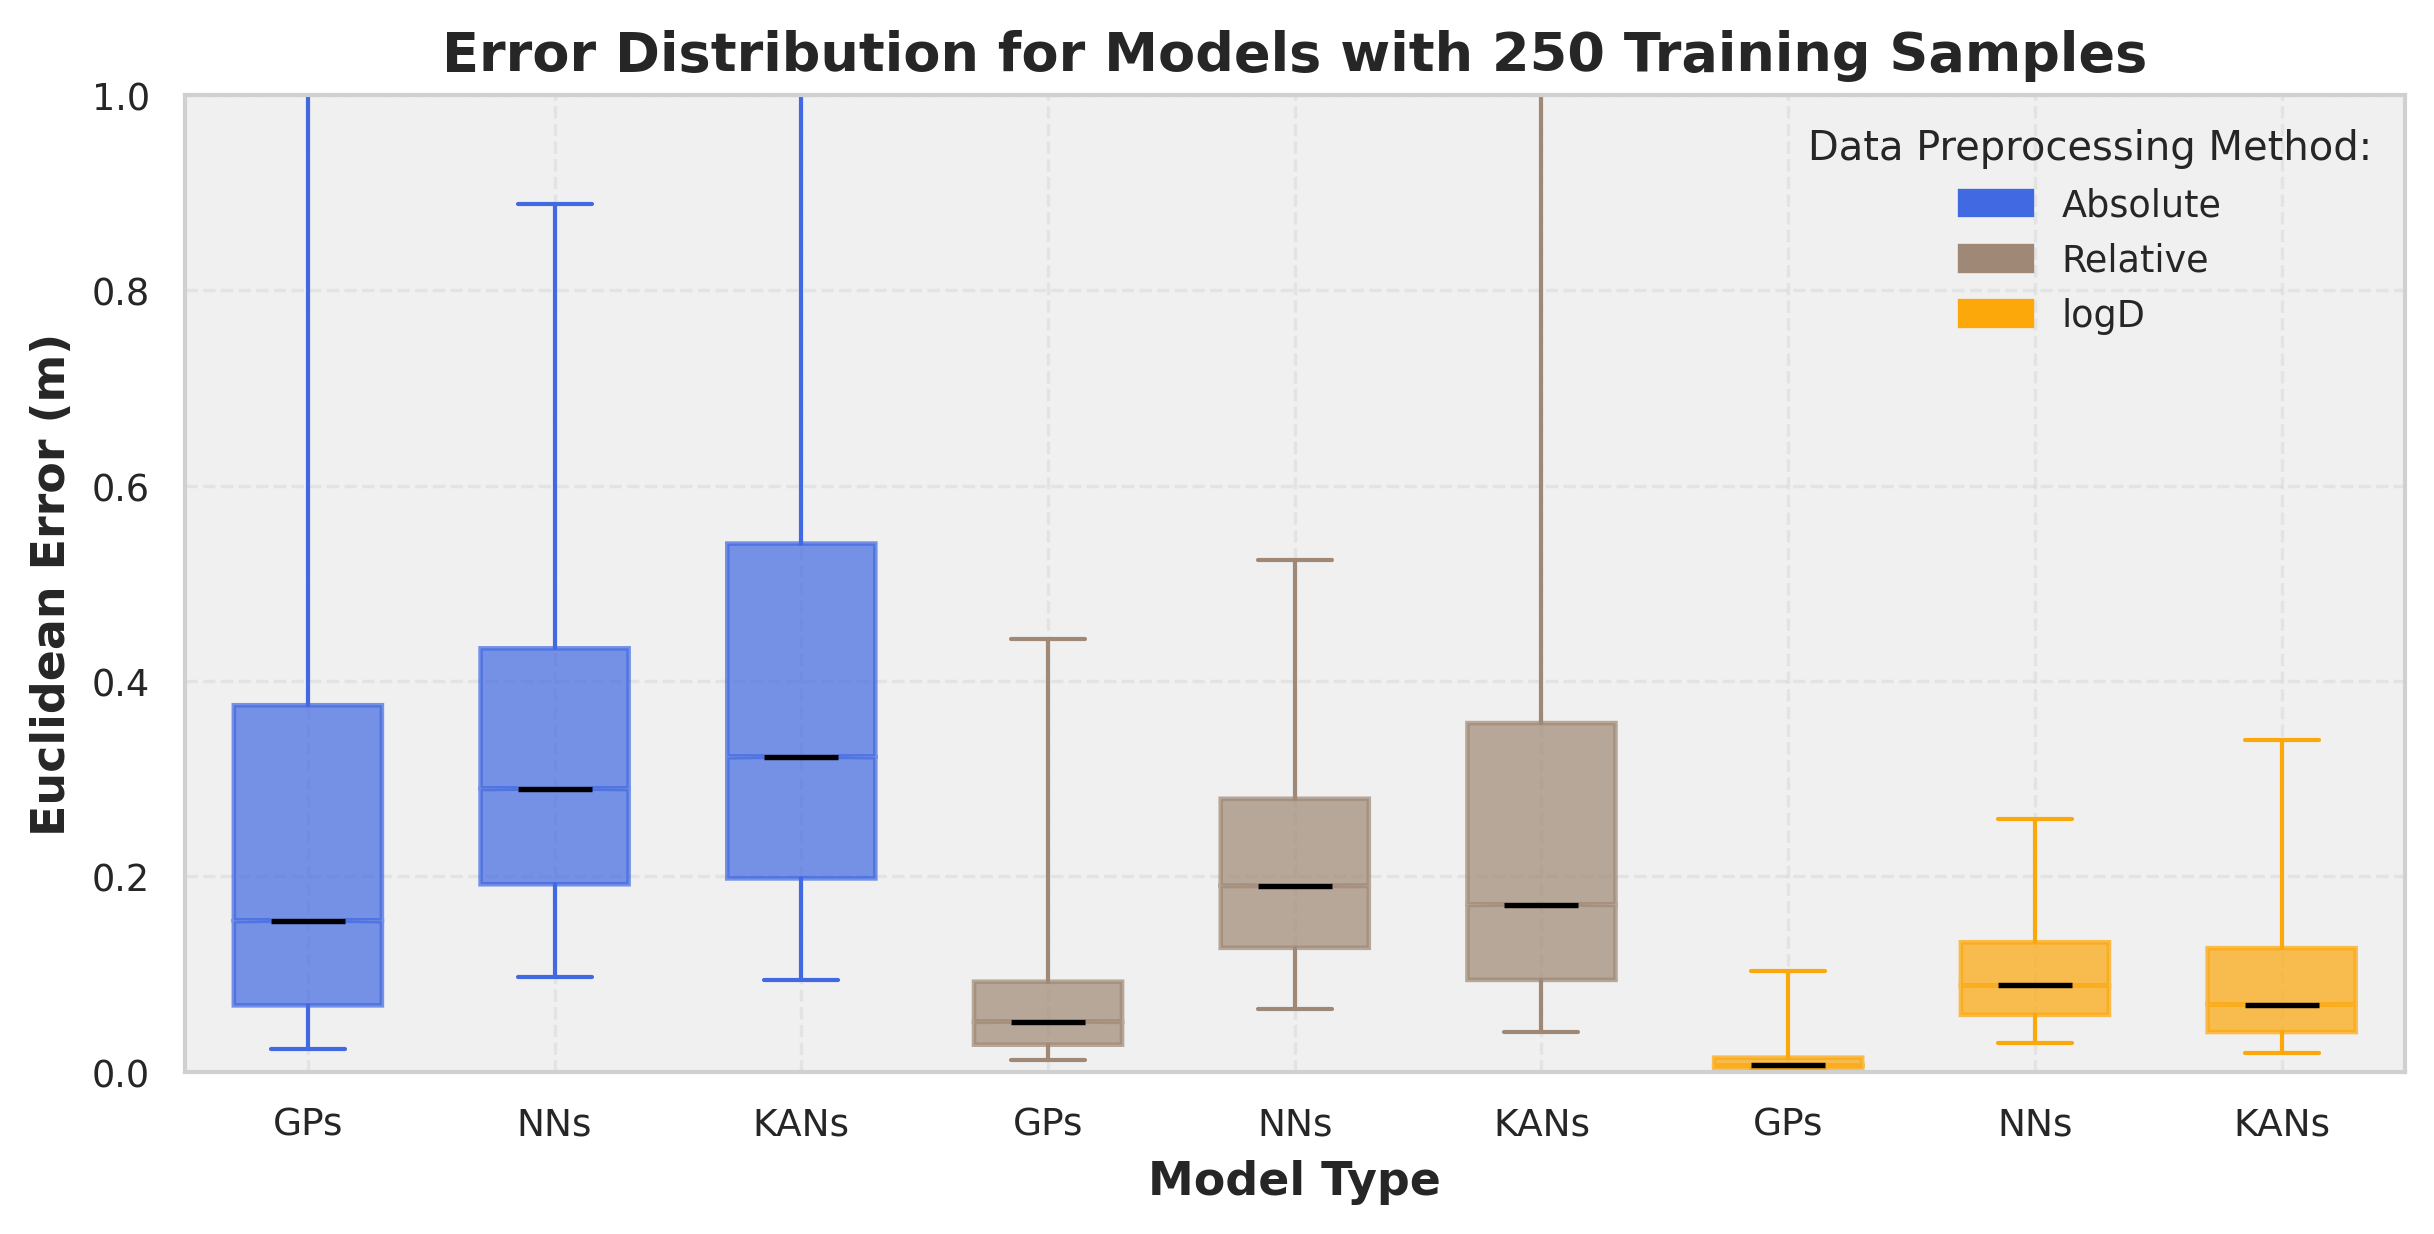

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── style ────────────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})

AX_FACECOLOUR = "#f0f0f0"

# ─── constants ─────────────────────────────────────────────────────────────
GND_PATH = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
PRED_N   = 250                       #  ← used in title

REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_DISPLAY     = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}

MODELS          = ["gps", "nns", "KANs"]
MODEL_DISPLAY   = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}

COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}

PATTERNS = {
    ("gps",  "absolute"):  "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"):  "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):     "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"):  "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"):  "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):     "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"):  "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"):  "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):     "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

# ─── helpers ───────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    d = pd.DataFrame({
        "diff_X": df1["X"] - df2["X"],
        "diff_Y": df1["Y"] - df2["Y"],
        "diff_Z": df1["Z"] - df2["Z"],
    })
    return np.sqrt(d["diff_X"]**2 + d["diff_Y"]**2 + d["diff_Z"]**2)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def collect_errors(model, rep, seeds=range(10)):
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in seeds:
        f = base / PATTERNS[(model, rep)].format(n=PRED_N, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(f)).values)
    return np.concatenate(errs)

# ─── gather data ───────────────────────────────────────────────────────────
box_data, box_labels = [], []
for rep in REPRESENTATIONS:        # Absolute • Relative • logD
    for mod in MODELS:             # GPs • NNs • KANs
        box_data.append(collect_errors(mod, rep))
        box_labels.append(MODEL_DISPLAY[mod])

# ─── plot (compact) ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.set_facecolor(AX_FACECOLOUR)

bp = ax.boxplot(
    box_data,
    notch=True,
    whis=[5, 95],
    showfliers=False,
    patch_artist=True,
    widths=0.6                          # candles almost touch
)

for i, box in enumerate(bp["boxes"]):
    rep = REPRESENTATIONS[i // len(MODELS)]
    col = COLOR_MAP[rep]
    box.set(facecolor=col, edgecolor=col, alpha=0.7, linewidth=1.1)
    bp["whiskers"][2*i  ].set_color(col)
    bp["whiskers"][2*i+1].set_color(col)
    bp["caps"][2*i  ].set_color(col)
    bp["caps"][2*i+1].set_color(col)

for med in bp["medians"]:
    med.set_color("black")
    med.set_linewidth(1.3)

# axis & labels
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=9)
ax.set_xlabel("Model Type",        fontsize=11, fontweight="bold")
ax.set_ylabel("Euclidean Error (m)", fontsize=11, fontweight="bold")
ax.set_title(f"Error Distribution for Models with {PRED_N} Training Samples",
             fontsize=13, fontweight="bold")

# legend
legend_items = [Patch(facecolor=c, edgecolor=c, label=REP_DISPLAY[r])
                for r, c in COLOR_MAP.items()]
ax.legend(handles=legend_items,
          title="Data Preprocessing Method:",
          frameon=False, loc="upper right")

plt.show()


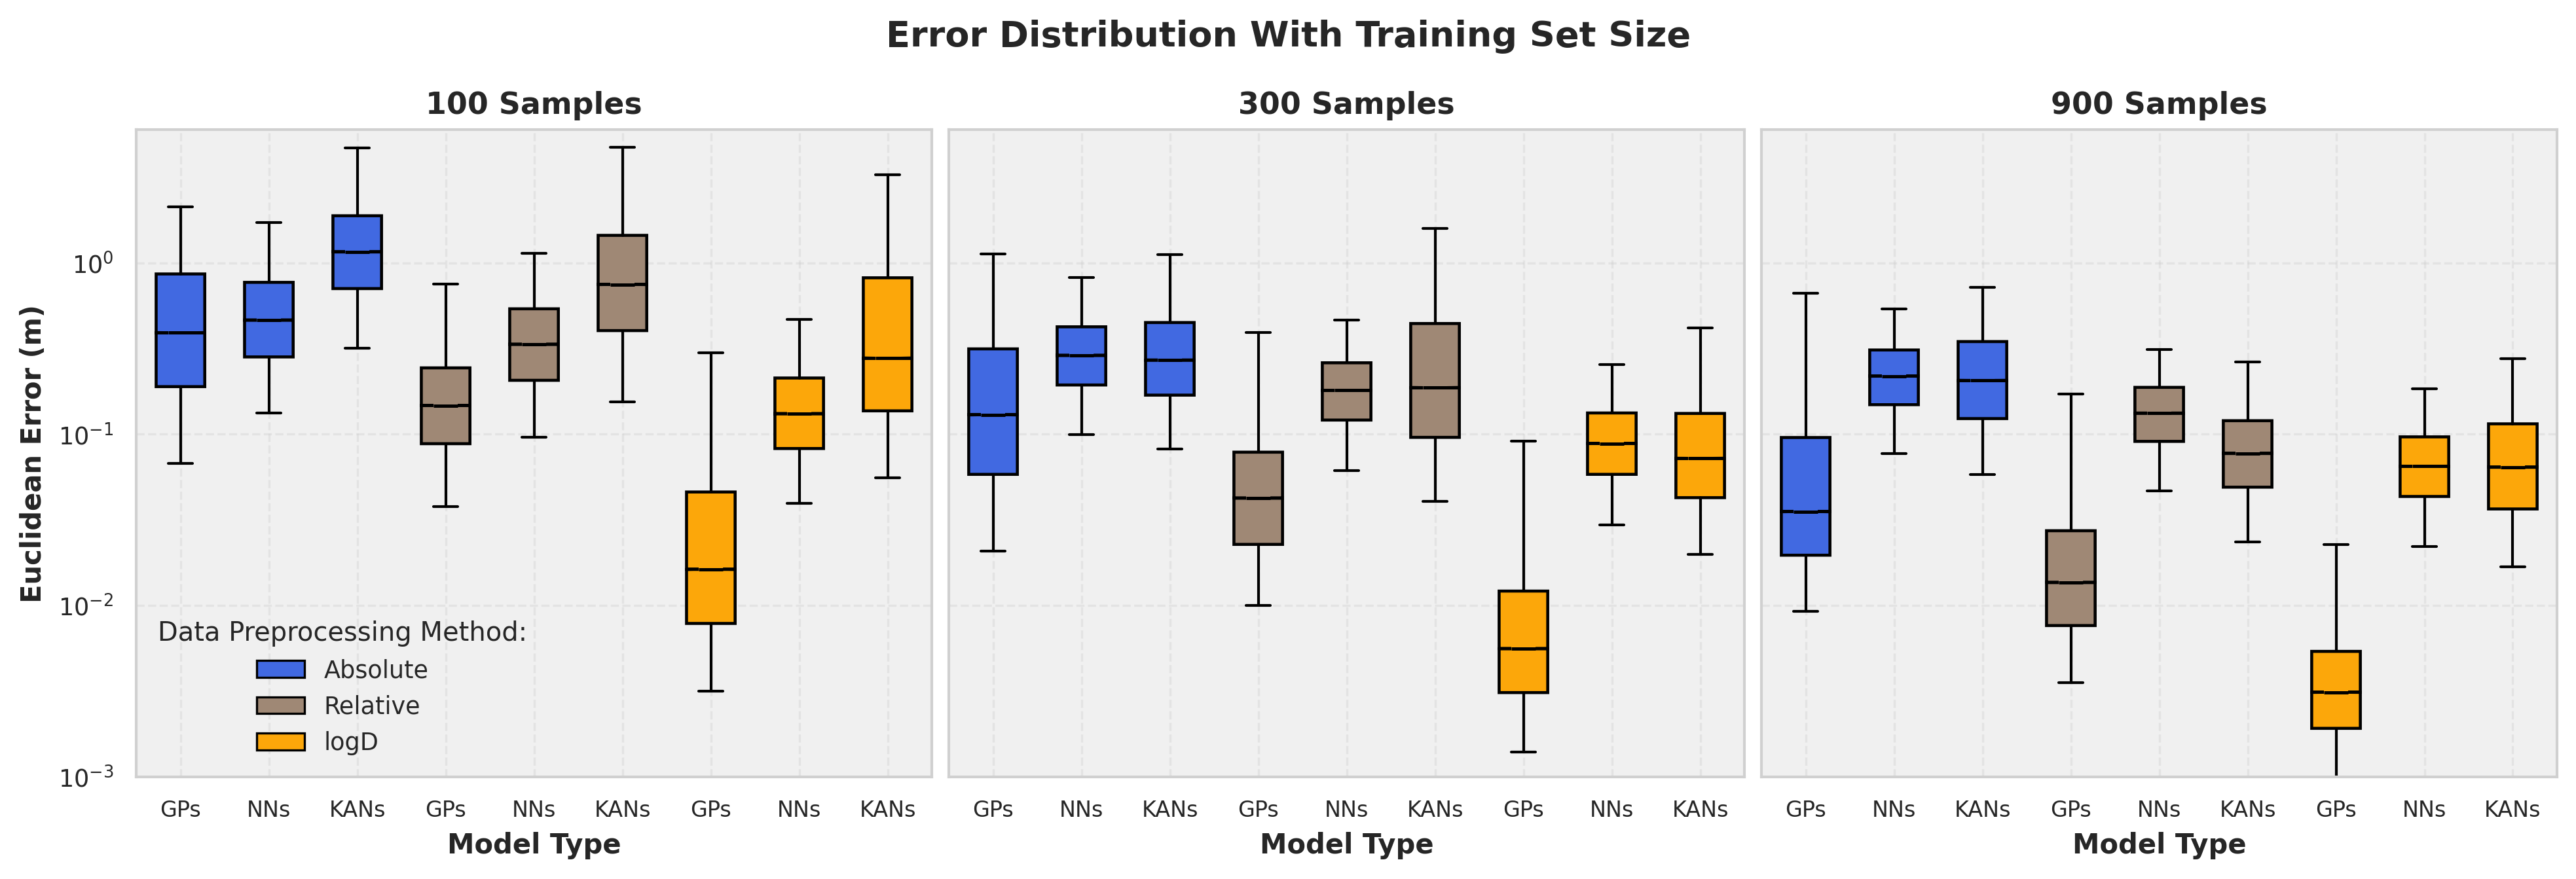

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── visual style ──────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── data definitions ─────────────────────────────────────────────────────
GND_PATH = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
N_LIST   = [100, 300, 900]                     # training-sample counts

REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}

MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}

COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}

PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

# ─── helpers ───────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def collect_errors(model, rep, n_samples, seeds=range(10)):
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in seeds:
        fn = base / PATTERNS[(model, rep)].format(n=n_samples, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(fn)))
    return np.concatenate(errs)

# ─── plot ──────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 3, figsize=(13, 4), sharey=True, constrained_layout=True)

for ax, N in zip(axs, N_LIST):

    # assemble data
    box_data, box_labels = [], []
    for rep in REPRESENTATIONS:
        for mod in MODELS:
            box_data.append(collect_errors(mod, rep, N))
            box_labels.append(MODEL_NAME[mod])

    # draw box-plot
    bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                    patch_artist=True, widths=0.55)

    # colour + outline
    for i, box in enumerate(bp["boxes"]):
        rep = REPRESENTATIONS[i // len(MODELS)]
        fill = COLOR_MAP[rep]
        box.set(facecolor=fill, edgecolor="black", linewidth=1.1)
        for item in ("whiskers", "caps"):
            bp[item][2*i  ].set_color("black")
            bp[item][2*i+1].set_color("black")
    for med in bp["medians"]:
        med.set_color("black"); med.set_linewidth(1.2)

    # axis settings – log scale 10⁻³ → 10⁰
    ax.set_facecolor(AX_BG)
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 6)
    ax.set_yticks([1, 1e-1, 1e-2, 1e-3])
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
    )

    ax.set_xticks(np.arange(1, len(box_labels) + 1))
    ax.set_xticklabels(box_labels, fontsize=8)
    ax.set_title(f"{N} Samples", fontsize=11, fontweight="bold")
    ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")

# shared y-label
axs[0].set_ylabel("Euclidean Error (m)", fontsize=10, fontweight="bold")

# legend – bottom-left inside the first axis
legend_patches = [Patch(facecolor=c, edgecolor="black", label=REP_NAME[r])
                  for r, c in COLOR_MAP.items()]
axs[0].legend(handles=legend_patches,
              title="Data Preprocessing Method:",
              frameon=False,
              loc="lower left")

fig.suptitle("Error Distribution With Training Set Size",
             fontsize=13, fontweight="bold", y=1.08)






fig.savefig("model_error_by_samples.svg", format="svg", dpi=400)   # ← new line

plt.show()


plt.show()


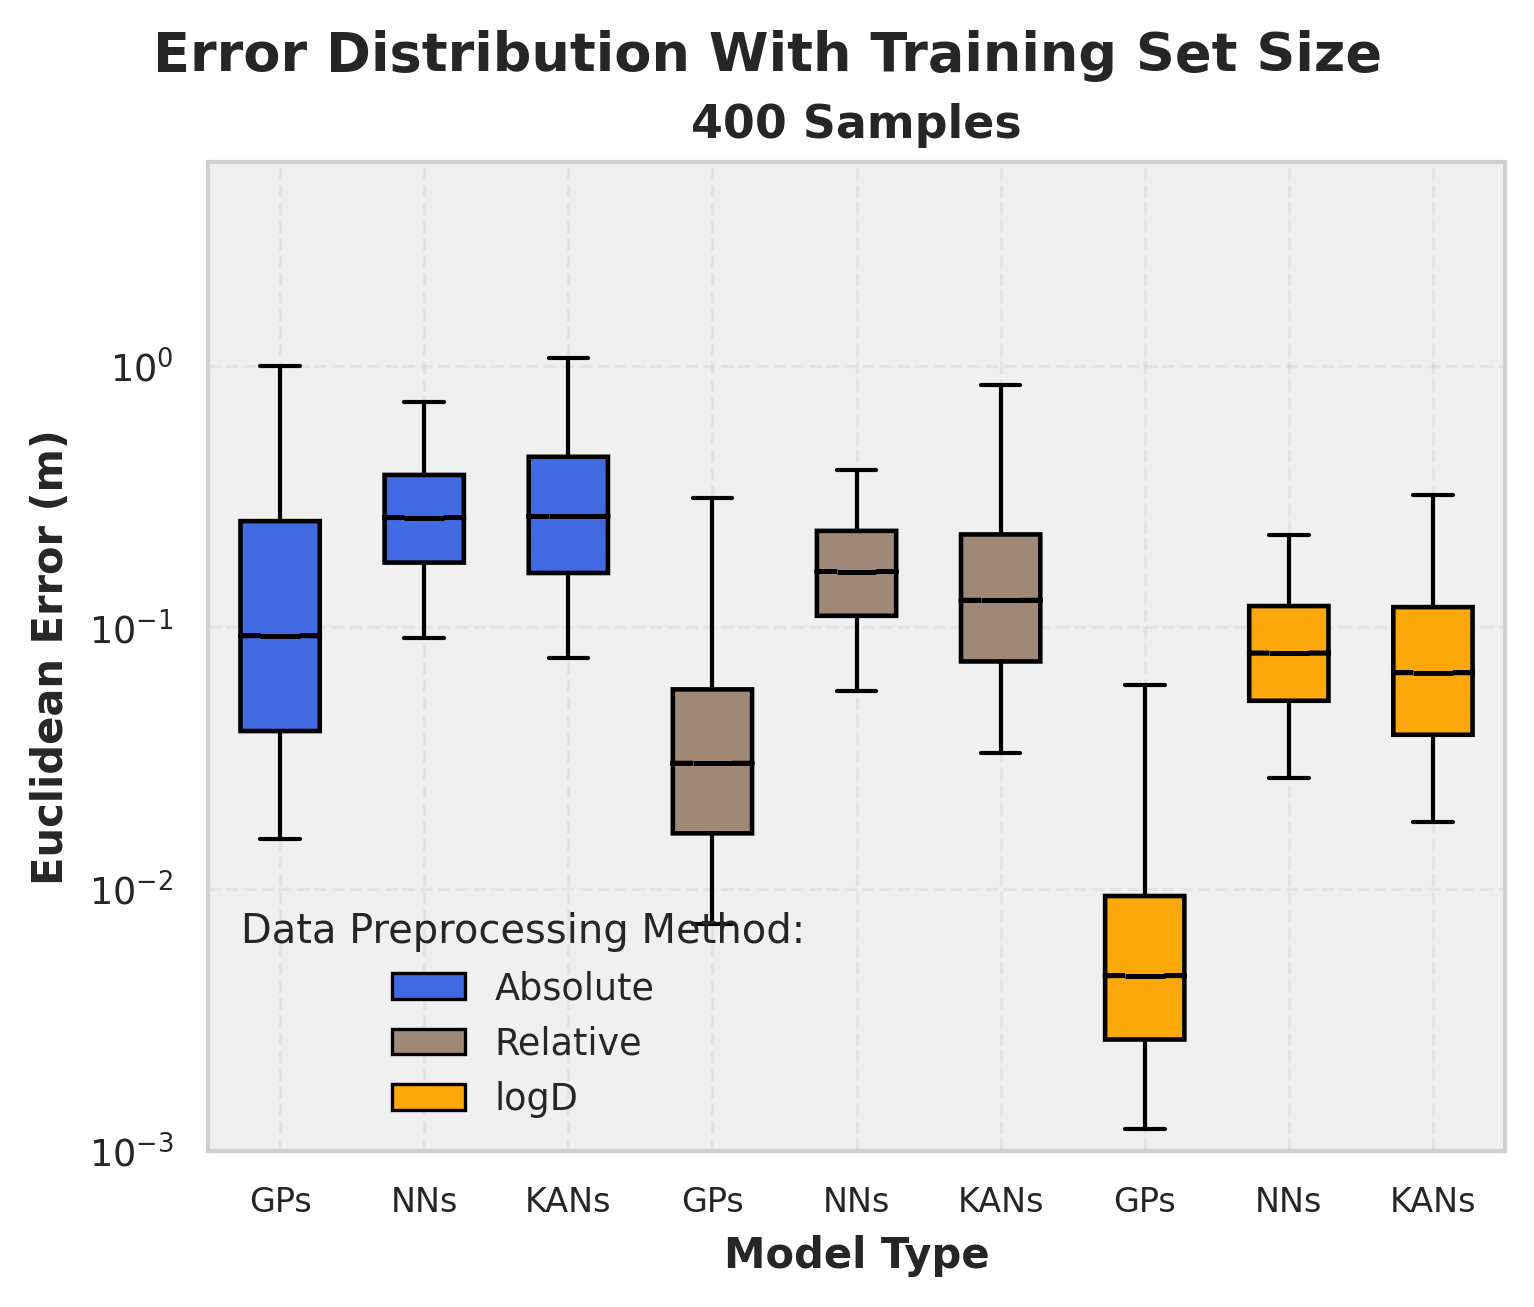

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── visual style ─────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── data definitions ────────────────────────────────────────────────────
GND_PATH    = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
N_SAMPLES   = 400                                       # ← single n
REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}
MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}
COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}
PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

# ─── helpers ──────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def collect_errors(model, rep, seeds=range(10)):
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in seeds:
        fn = base / PATTERNS[(model, rep)].format(n=N_SAMPLES, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(fn)))
    return np.concatenate(errs)

# ─── plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

# assemble data
box_data, box_labels = [], []
for rep in REPRESENTATIONS:
    for mod in MODELS:
        box_data.append(collect_errors(mod, rep))
        box_labels.append(MODEL_NAME[mod])

# draw box-plot
bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                patch_artist=True, widths=0.55)

# colour + outline
for i, box in enumerate(bp["boxes"]):
    rep = REPRESENTATIONS[i // len(MODELS)]
    fill = COLOR_MAP[rep]
    box.set(facecolor=fill, edgecolor="black", linewidth=1.1)
    for item in ("whiskers", "caps"):
        bp[item][2*i  ].set_color("black")
        bp[item][2*i+1].set_color("black")
for med in bp["medians"]:
    med.set_color("black"); med.set_linewidth(1.2)

# axes – log scale 10⁻³ → 6 m
ax.set_facecolor(AX_BG)
ax.set_yscale("log")
ax.set_ylim(1e-3, 6)
ax.set_yticks([1, 1e-1, 1e-2, 1e-3])
ax.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
)

ax.set_xticks(np.arange(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels, fontsize=8)
ax.set_title(f"{N_SAMPLES} Samples", fontsize=11, fontweight="bold")
ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")
ax.set_ylabel("Euclidean Error (m)", fontsize=10, fontweight="bold")

# legend – bottom-left inside the axis
legend_patches = [Patch(facecolor=c, edgecolor="black", label=REP_NAME[r])
                  for r, c in COLOR_MAP.items()]
ax.legend(handles=legend_patches,
          title="Data Preprocessing Method:",
          frameon=False,
          loc="lower left")

# overall title
fig.suptitle("Error Distribution With Training Set Size",
             fontsize=13, fontweight="bold", y=1.05)

# save SVG at 400 dpi
fig.savefig("model_error_400_samples.svg", format="svg", dpi=400)

plt.show()


In [4]:
# ─── imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── visual style ────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── data definitions ────────────────────────────────────────────────────
GND_PATH        = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}
MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}
COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}
PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}

# ─── helpers ─────────────────────────────────────────────────────────────
def compute_difference_norms(df1: pd.DataFrame, df2: pd.DataFrame):
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def collect_errors(model, rep, n_samples, seeds=range(10)):
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in seeds:
        fn = base / PATTERNS[(model, rep)].format(n=n_samples, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(fn)))
    return np.concatenate(errs)

# ─── main loop over training sizes ───────────────────────────────────────
for n in range(50, 1501, 50):
    print(f"Rendering n = {n} …")

    box_data, box_labels = [], []
    for rep in REPRESENTATIONS:
        for mod in MODELS:
            box_data.append(collect_errors(mod, rep, n))
            box_labels.append(MODEL_NAME[mod])

    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

    bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                    patch_artist=True, widths=0.55)

    for i, box in enumerate(bp["boxes"]):
        rep = REPRESENTATIONS[i // len(MODELS)]
        fill = COLOR_MAP[rep]
        box.set(facecolor=fill, edgecolor="black", linewidth=1.1)
        for part in ("whiskers", "caps"):
            bp[part][2*i  ].set_color("black")
            bp[part][2*i+1].set_color("black")
    for med in bp["medians"]:
        med.set_color("black"); med.set_linewidth(1.2)

    ax.set_facecolor(AX_BG)
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 6)
    ax.set_yticks([1, 1e-1, 1e-2, 1e-3])
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
    )

    ax.set_xticks(np.arange(1, len(box_labels) + 1))
    ax.set_xticklabels(box_labels, fontsize=8)
    ax.set_title(f"{n} Samples", fontsize=11, fontweight="bold")
    ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")
    ax.set_ylabel("Euclidean Error (m)", fontsize=10, fontweight="bold")

    legend_patches = [Patch(facecolor=c, edgecolor="black", label=REP_NAME[r])
                      for r, c in COLOR_MAP.items()]
    ax.legend(handles=legend_patches, title="Data Preprocessing Method:",
              frameon=False, loc="lower left")

    fig.suptitle("Error Distribution With Training Set Size",
                 fontsize=13, fontweight="bold", y=1.05)

    fig.savefig(f"model_error_{n}_samples.svg", format="svg", dpi=400)
    plt.close(fig)

print("✓ All SVGs saved.")


Rendering n = 50 …
Rendering n = 100 …
Rendering n = 150 …
Rendering n = 200 …
Rendering n = 250 …
Rendering n = 300 …
Rendering n = 350 …
Rendering n = 400 …
Rendering n = 450 …
Rendering n = 500 …
Rendering n = 550 …
Rendering n = 600 …
Rendering n = 650 …
Rendering n = 700 …
Rendering n = 750 …
Rendering n = 800 …
Rendering n = 850 …
Rendering n = 900 …
Rendering n = 950 …
Rendering n = 1000 …
Rendering n = 1050 …
Rendering n = 1100 …
Rendering n = 1150 …
Rendering n = 1200 …
Rendering n = 1250 …
Rendering n = 1300 …
Rendering n = 1350 …
Rendering n = 1400 …
Rendering n = 1450 …
Rendering n = 1500 …
✓ All SVGs saved.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

# ─── style (unchanged) ───────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ─── constants (paths, mappings) ──────────────────────────────────────────
GND_PATH  = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
SEEDS     = range(10)

REPRESENTATIONS = ["absolute", "relative", "log_d"]
REP_NAME        = {"absolute": "Absolute", "relative": "Relative", "log_d": "logD"}

MODELS          = ["gps", "nns", "KANs"]
MODEL_NAME      = {"gps": "GPs", "nns": "NNs", "KANs": "KANs"}

COLOR_MAP = {
    "absolute": (65/255, 105/255, 225/255),
    "relative": (159/255, 136/255, 117/255),
    "log_d":    (252/255, 167/255,  10/255),
}

PATTERNS = {
    ("gps",  "absolute"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "relative"): "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("gps",  "log_d"):    "rss_n={n}_noise=0.0_seed={seed}.csv",
    ("nns",  "absolute"): "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "relative"): "relative_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("nns",  "log_d"):    "full_model_rss_n={n}_noise=0.0_seed={seed}_test_noise=0.0.csv",
    ("KANs", "absolute"): "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
    ("KANs", "relative"): "KAN_predictions_relative_rss_n={n}_noise=0.0_seed={seed}.csv",  # ← fixed
    ("KANs", "log_d"):    "KAN_predictions_rss_n={n}_noise=0.0_seed={seed}.csv",
}


AXIS_ORDER   = ["X", "Y", "Z"]
HATCH_MAP    = {"X": "", "Y": "///", "Z": "\\\\"}

# ─── helpers ──────────────────────────────────────────────────────────────
df_gnd = pd.read_csv(GND_PATH)[AXIS_ORDER]

def axis_errors(model, rep, axis, n_samples):
    """Absolute error array for one axis and training size n_samples."""
    base = Path(f"./predictions/{model}_{rep}")
    errs = []
    for s in SEEDS:
        fn = base / PATTERNS[(model, rep)].format(n=n_samples, seed=s)
        errs.append(np.abs(df_gnd[axis] - pd.read_csv(fn)[axis]).values)
    return np.concatenate(errs)

def make_rep_figure(n_samples):
    """Create and save the three-panel ‘by representation’ figure for a given n."""
    fig, axs = plt.subplots(1, 3, figsize=(15, 4),
                            sharey=True, constrained_layout=True)

    for ax, rep in zip(axs, REPRESENTATIONS):
        box_data, hatch_list, box_labels = [], [], []

        for mod in MODELS:                 # GPs, NNs, KANs
            for axis in AXIS_ORDER:        # X, Y, Z
                box_data.append(axis_errors(mod, rep, axis, n_samples))
                hatch_list.append(HATCH_MAP[axis])
            box_labels.append(MODEL_NAME[mod])

        bp = ax.boxplot(box_data, notch=True, whis=[5, 95], showfliers=False,
                        patch_artist=True, widths=0.6)

        for i, box in enumerate(bp["boxes"]):
            box.set(facecolor=COLOR_MAP[rep],
                    edgecolor="black", linewidth=1.1,
                    hatch=hatch_list[i])
            for part in ("whiskers", "caps"):
                bp[part][2*i  ].set_color("black")
                bp[part][2*i+1].set_color("black")
        for med in bp["medians"]:
            med.set_color("black"); med.set_linewidth(1.2)

        ax.set_facecolor(AX_BG)
        ax.set_yscale("log")
        ax.set_ylim(1e-4, 1)
        ax.set_yticks([1, 1e-1, 1e-2, 1e-3, 1e-4])
        ax.get_yaxis().set_major_formatter(
            plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
        )

        ax.set_xticks([2, 5, 8])           # centre of each model triplet
        ax.set_xticklabels(box_labels, fontsize=9)
        ax.set_title(REP_NAME[rep], fontsize=11, fontweight="bold")
        ax.set_xlabel("Model Type", fontsize=10, fontweight="bold")

    axs[0].set_ylabel("Absolute Error (m)", fontsize=10, fontweight="bold")

    legend_patches = [Patch(facecolor="white", edgecolor="black",
                            hatch=HATCH_MAP[a], label=f"|Δ{a}|")
                      for a in AXIS_ORDER]
    axs[0].legend(handles=legend_patches, title="Coordinate Axis:",
                  frameon=False, loc="lower left")

    fig.suptitle(f"Coordinate-wise Error Distribution • n = {n_samples}",
                 fontsize=13, fontweight="bold", y=1.08)

    out_name = f"model_error_{n_samples}_samples_by_rep.svg"
    fig.savefig(out_name, format="svg", dpi=400)
    plt.close(fig)

# ─── main loop ────────────────────────────────────────────────────────────
for n in range(50, 1501, 50):
    print(f"Rendering n = {n} …")
    make_rep_figure(n)

print("All figures saved!")


Rendering n = 50 …
Rendering n = 100 …
Rendering n = 150 …
Rendering n = 200 …
Rendering n = 250 …
Rendering n = 300 …
Rendering n = 350 …
Rendering n = 400 …
Rendering n = 450 …
Rendering n = 500 …
Rendering n = 550 …
Rendering n = 600 …
Rendering n = 650 …
Rendering n = 700 …
Rendering n = 750 …
Rendering n = 800 …
Rendering n = 850 …
Rendering n = 900 …
Rendering n = 950 …
Rendering n = 1000 …
Rendering n = 1050 …
Rendering n = 1100 …
Rendering n = 1150 …
Rendering n = 1200 …
Rendering n = 1250 …
Rendering n = 1300 …
Rendering n = 1350 …
Rendering n = 1400 …
Rendering n = 1450 …
Rendering n = 1500 …
All figures saved!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── styling ───────────────────────────────────────────────────────────────
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor":  "#d0d0d0",
    "grid.alpha":      0.35,
    "grid.linestyle":  "--",
    "figure.dpi":      300,
})
AX_BG = "#f0f0f0"

# ── constants ─────────────────────────────────────────────────────────────
GND_PATH     = "./3D-Data/Measured/gnd_n=50_noise=0.0.csv"
MODEL_DIR    = "./predictions/gps_log_d"                # log-d GP folder

NOISE_LEVELS = [0.0, 6e-06, 1.9e-05, 6e-05, 1.9e-04]
X_TICK_LABEL = [
    "∞ dB SNR (no noise)",
    "60 dB SNR",
    "50 dB SNR",
    "40 dB SNR",
    "30 dB SNR",
]

FILE_PATTERN = "rss_n={n}_noise={noise}_seed={seed}.csv"
LOGD_COLOR   = (252/255, 167/255, 10/255)               # same orange-gold

# ── helpers ───────────────────────────────────────────────────────────────
def compute_difference_norms(df1, df2):
    diff = df1[["X", "Y", "Z"]] - df2[["X", "Y", "Z"]]
    return np.linalg.norm(diff, axis=1)

df_gnd = pd.read_csv(GND_PATH)[["X", "Y", "Z"]]

def load_errors(n_train, noise):
    seeds = range(10) if noise == 0.0 else [0]
    errs  = []
    base  = Path(MODEL_DIR)
    for s in seeds:
        f = base / FILE_PATTERN.format(n=n_train, noise=noise, seed=s)
        errs.append(compute_difference_norms(df_gnd, pd.read_csv(f)))
    return np.concatenate(errs)

# ── main loop over n = 50 … 1500 ──────────────────────────────────────────
for n_train in range(50, 1501, 50):

    # gather errors for every noise level
    box_data = [load_errors(n_train, nz) for nz in NOISE_LEVELS]

    # ─ plot ─
    fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
    ax.set_facecolor(AX_BG)

    bp = ax.boxplot(
        box_data, notch=True, whis=[5, 95], showfliers=False,
        patch_artist=True, widths=0.6
    )

    for box, med in zip(bp["boxes"], bp["medians"]):
        box.set(facecolor=LOGD_COLOR, edgecolor="black", linewidth=1.1)
        med.set_color("black"); med.set_linewidth(1.2)
    for item in ("whiskers", "caps"):
        for line in bp[item]:
            line.set_color("black")

    # log y-axis 10⁻³ → 10⁰
    ax.set_yscale("log")
    ax.set_ylim(1e-3, 1)
    ax.set_yticks([1, 1e-1, 1e-2, 1e-3])
    ax.get_yaxis().set_major_formatter(
        plt.FuncFormatter(lambda y, _: f"$10^{{{int(np.log10(y))}}}$")
    )

    ax.set_xticks(np.arange(1, len(X_TICK_LABEL) + 1))
    ax.set_xticklabels(X_TICK_LABEL, fontsize=9)
    ax.set_xlabel("Channel Signal-to-Noise Ratio", fontsize=11, fontweight="bold")
    ax.set_ylabel("Euclidean Error (m)",           fontsize=11, fontweight="bold")
    ax.set_title(f"Noise Impact on logD GP Model  (n = {n_train})",
                 fontsize=13, fontweight="bold")

    # save SVG
    out_name = f"gp_logd_noise_impact_n_{n_train}.svg"
    fig.savefig(out_name, format="svg", dpi=400)
    plt.close(fig)     # keep memory usage low

print("✓ All figures saved as gp_logd_noise_impact_n_<n>.svg")


✓ All figures saved as gp_logd_noise_impact_n_<n>.svg
